In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
IMAGE_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
SEED = 42

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="reflect"
)

train_generator = train_gen.flow_from_directory(
    "dataset/train",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True,
    seed=SEED
)

Found 6285 images belonging to 6 classes.


In [3]:
valid_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_generator = valid_gen.flow_from_directory(
    "dataset/val",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 896 images belonging to 6 classes.


In [4]:
test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_gen.flow_from_directory(
    "dataset/test",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 1802 images belonging to 6 classes.


In [5]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
num_classes = 6

base_model = EfficientNetB0(
    include_top=False,
    input_shape=input_shape,
    weights="imagenet",
    pooling="avg"
)
base_model.trainable = False  # freeze backbone for a stable warmup

model = models.Sequential([
    layers.Input(shape=input_shape),
    base_model,
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [8]:
train_steps = len(train_generator)
valid_steps = len(valid_generator)
train_steps, valid_steps

(197, 28)

In [9]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

checkpoint = callbacks.ModelCheckpoint(
    "best_effnetb0.keras",
    monitor="val_loss",
    save_best_only=True
)

In [10]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 118s 570ms/step - accuracy: 0.5354 - loss: 1.2888 - val_accuracy: 0.8080 - val_loss: 0.7288 - learning_rate: 1.0000e-04
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 118s 599ms/step - accuracy: 0.7599 - loss: 0.7299 - val_accuracy: 0.8627 - val_loss: 0.4726 - learning_rate: 1.0000e-04
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 119s 604ms/step - accuracy: 0.8148 - loss: 0.5591 - val_accuracy: 0.8884 - val_loss: 0.3794 - learning_rate: 1.0000e-04
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 118s 601ms/step - accuracy: 0.8407 - loss: 0.4666 - val_accuracy: 0.9074 - val_loss: 0.3159 - learning_rate: 1.0000e-04
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 114s 577ms/step - accuracy: 0.8630 - loss: 0.4052 - val_accuracy: 0.9185 - val_loss: 0.2821 - learning_rate: 1.0000e-04
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 117s 595ms/step - accuracy: 0.8719 - loss: 0.3796 - val_accuracy: 0.9208 - val_loss: 0.2522 - learning_rate: 1.0000e-04
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
# Fine-tune upper layers once warmup converges
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

fine_tune_epochs = 10
history_ft = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=valid_generator,
    validation_steps=valid_steps,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 143s 682ms/step - accuracy: 0.8756 - loss: 0.3839 - val_accuracy: 0.9408 - val_loss: 0.1659 - learning_rate: 3.0000e-05
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 139s 706ms/step - accuracy: 0.9219 - loss: 0.2422 - val_accuracy: 0.9598 - val_loss: 0.1349 - learning_rate: 3.0000e-05
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 140s 712ms/step - accuracy: 0.9378 - loss: 0.1862 - val_accuracy: 0.9576 - val_loss: 0.1302 - learning_rate: 9.0000e-06
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 138s 698ms/step - accuracy: 0.9445 - loss: 0.1783 - val_accuracy: 0.9632 - val_loss: 0.1216 - learning_rate: 9.0000e-06
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 140s 709ms/step - accuracy: 0.9473 - loss: 0.1591 - val_accuracy: 0.9621 - val_loss: 0.1150 - learning_rate: 9.0000e-06
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 127s 644ms/step - accuracy: 0.9464 - loss: 0.1565 - val_accuracy: 0.9665 - val_loss: 0.1096 - learning_rate: 9.0000e-06
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
test_steps = len(test_generator)
test_loss, test_acc = model.evaluate(test_generator, steps=test_steps, verbose=1)
print({"test_loss": test_loss, "test_accuracy": test_acc})

57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 577ms/step - accuracy: 0.9667 - loss: 0.0968
{'test_loss': 0.09675689786672592, 'test_accuracy': 0.9667036533355713}


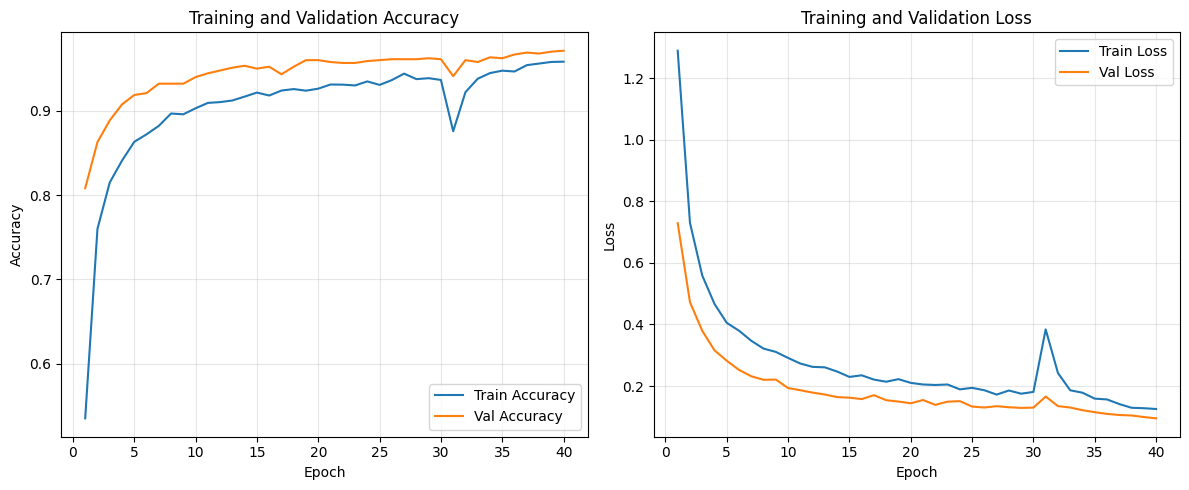

In [13]:
# Plot training and validation accuracy/loss
import matplotlib.pyplot as plt
import numpy as np

# Collect metrics from warmup and optional fine-tune
acc = list(history.history.get('accuracy', []))
val_acc = list(history.history.get('val_accuracy', []))
loss = list(history.history.get('loss', []))
val_loss = list(history.history.get('val_loss', []))

try:
    acc += list(history_ft.history.get('accuracy', []))
    val_acc += list(history_ft.history.get('val_accuracy', []))
    loss += list(history_ft.history.get('loss', []))
    val_loss += list(history_ft.history.get('val_loss', []))
except NameError:
    pass

epochs = np.arange(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# Save trained model to models directory, robust to working dir
from pathlib import Path
import os

# Detect models directory relative to notebook working directory
candidates = [Path('models'), Path('../models'), Path('../../models')]
models_dir = None
for p in candidates:
    if p.exists():
        models_dir = p
        break
if models_dir is None:
    models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

save_path = models_dir / 'tomato_effnetb0.keras'
model.save(save_path)
print(f"Saved model to: {save_path.resolve()}")

# Optionally also save best checkpoint copy if exists
checkpoint_path = Path('best_effnetb0.keras')
if checkpoint_path.exists():
    dest_ckpt = models_dir / 'best_effnetb0.keras'
    import shutil
    shutil.copy2(checkpoint_path, dest_ckpt)
    print(f"Copied best checkpoint to: {dest_ckpt.resolve()}")

Saved model to: C:\Users\2021ICTS28\Desktop\Tomato_Disease_Prediction_System\models\tomato_effnetb0.keras
Copied best checkpoint to: C:\Users\2021ICTS28\Desktop\Tomato_Disease_Prediction_System\models\best_effnetb0.keras
